1. Business Understanding

1.1 Project Overview

A Kenyan retail business selling across cities (Nairobi, Mombasa, Kisumu, Eldoret, Nakuru) through Online / Retail / Agent channels, with delivery performance, returns, costs, and profitability tracked.

Operational Profitability & Delivery Performance Analysis. Multi-Channel Retail Business – Kenya

2.2 The Business Problem:

We want to understand what drives profitability, returns, and customer satisfaction, and identify operational issues in delivery performance across regions and sales channels.

2.3 Business/Research Questions:

1. Which category–channel combinations generate the highest and lowest profit margins?

2. Does higher discounting increase sales but reduce profitability?

3. How do delivery delays affect customer satisfaction and return rates?

4. Which regions systematically underperform on on-time delivery?

5. What are the major operational cost drivers affecting profit?

2. Data Understanding

In this phase, we explore the structure, quality, and characteristics of the dataset. The dataset contains 5,040 orders and 25 variables, structured across six business dimensions.

In [280]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [281]:
# Load the Dataset
df = pd.read_csv("synthetic_kenya_retail_logistics.csv")
df.head()

,order_id,order_date,region,city,channel,segment,category,subcategory,payment_method,quantity,...,actual_delivery_days,returned,customer_satisfaction,shipping_cost,cogs,payment_fee,net_sales,profit,staff_id,customer_id
0,ORD-KYRM2M37,2025-03-20,Eldoret,Kapsoya,Retail,Consumer,Grocery,Beverages,M-Pesa,3,...,0,0,4.36,145.74,351.83,2.28,456.71,-43.15,S-WCUKHG,C-5MBPE1AQ
1,ORD-UUGGJNLF,2024-07-05,Kisumu,Manyatta,Retail,Consumer,Grocery,Dry Goods,M-Pesa,7,...,2,0,4.41,107.36,2104.73,13.80,2759.97,534.08,S-G9SCRH,C-TAZUQM6X
2,ORD-2LASMKHU,2025-01-02,Mombasa,Nyali,Online,Consumer,Building Materials,Steel,Card,5,...,0,0,3.72,463.12,5388.00,159.60,7254.43,1243.71,NaN,C-J4NZTBD8
3,ORD-VCNWSTDM,2025-09-03,Mombasa,Nyali,Online,SME,Grocery,Beverages,M-Pesa,5,...,3,0,3.66,779.95,678.06,4.15,829.99,-632.16,NaN,C-TRA39OTV
4,ORD-BPU90RN2,2024-10-20,Nairobi,Westlands,Retail,Consumer,Grocery,Dairy,M-Pesa,4,...,4,0,3.45,137.72,611.17,4.34,868.47,115.23,S-MBKHZP,C-FJBLSXZ3


In [282]:
# Check the dataset shape(rows & Columns)
df.shape

(5040, 25)

In [283]:
# Check the dataset columns/features
df.columns

Index(['order_id', 'order_date', 'region', 'city', 'channel', 'segment',
       'category', 'subcategory', 'payment_method', 'quantity', 'unit_price',
       'discount_rate', 'distance_km', 'weight_kg', 'promised_delivery_days',
       'actual_delivery_days', 'returned', 'customer_satisfaction',
       'shipping_cost', 'cogs', 'payment_fee', 'net_sales', 'profit',
       'staff_id', 'customer_id'],
      dtype='object')

In [284]:
# Check column types
df.dtypes

order_id                   object
order_date                 object
region                     object
city                       object
channel                    object
segment                    object
category                   object
subcategory                object
payment_method             object
quantity                    int64
unit_price                float64
discount_rate             float64
distance_km               float64
weight_kg                 float64
promised_delivery_days      int64
actual_delivery_days        int64
returned                    int64
customer_satisfaction     float64
shipping_cost             float64
cogs                      float64
payment_fee               float64
net_sales                 float64
profit                    float64
staff_id                   object
customer_id                object
dtype: object

In [285]:
# Summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5040 non-null   object 
 1   order_date              5040 non-null   object 
 2   region                  5040 non-null   object 
 3   city                    4957 non-null   object 
 4   channel                 5040 non-null   object 
 5   segment                 5040 non-null   object 
 6   category                5040 non-null   object 
 7   subcategory             5040 non-null   object 
 8   payment_method          4941 non-null   object 
 9   quantity                5040 non-null   int64  
 10  unit_price              5040 non-null   float64
 11  discount_rate           5040 non-null   float64
 12  distance_km             4900 non-null   float64
 13  weight_kg               4828 non-null   float64
 14  promised_delivery_days  5040 non-null   

In [286]:
# Check the missing columns
df.isna().sum().sort_values(ascending=False)

staff_id                  2118
customer_satisfaction      300
weight_kg                  212
distance_km                140
payment_method              99
city                        83
order_id                     0
region                       0
order_date                   0
subcategory                  0
category                     0
segment                      0
channel                      0
discount_rate                0
promised_delivery_days       0
unit_price                   0
quantity                     0
returned                     0
actual_delivery_days         0
cogs                         0
shipping_cost                0
payment_fee                  0
net_sales                    0
profit                       0
customer_id                  0
dtype: int64

In [287]:
#  Check the % of missing columns
df.isna().sum().sort_values(ascending=False)*100/len(df)

staff_id                  42.023810
customer_satisfaction      5.952381
weight_kg                  4.206349
distance_km                2.777778
payment_method             1.964286
city                       1.646825
order_id                   0.000000
region                     0.000000
order_date                 0.000000
subcategory                0.000000
category                   0.000000
segment                    0.000000
channel                    0.000000
discount_rate              0.000000
promised_delivery_days     0.000000
unit_price                 0.000000
quantity                   0.000000
returned                   0.000000
actual_delivery_days       0.000000
cogs                       0.000000
shipping_cost              0.000000
payment_fee                0.000000
net_sales                  0.000000
profit                     0.000000
customer_id                0.000000
dtype: float64

In [288]:
# Check duplicates
df.duplicated().sum()

np.int64(40)

Data quality issues found:
- Wrong data types for the variable column (order_date).
- Dataset has missing values for the following variables:
   > Customer_satisfaction - 6%,
   > Weight_kg - 4.2%,
   > Distance_km - 2.8%,
   > Payment_method - 1.9%,
   > City - 1.6%,
   > Staff_id - 42%
- Dataset has duplicate of (40 records).


3.Data Preparation (Cleaning)

Before visualizing, we handle missing values to ensure our charts accurately reflect the population. We will use a simple imputation strategy (mode/median) for this exploratory phase.

3.1  Fix Types

In [289]:
# Convert the dtypes
cat_col = ["region","city","channel","segment","category","subcategory","payment_method"]
for col in cat_col:
    df[col] = df[col].astype("category")

df["order_date"] = pd.to_datetime(df["order_date"])

df["returned"] = df["returned"].astype("bool")

In [290]:
df["order_date"].dtypes # Convert to datetime dtype

dtype('<M8[ns]')

In [291]:
# df["returned"].dtypes # Convert to bool dtype

3.2 Drop Columns

In [292]:
# Drop insignifacants columns i.e the unique identifiers
df.drop(["order_id","staff_id","customer_id"], axis=1 , inplace= True)

In [293]:
df.columns

Index(['order_date', 'region', 'city', 'channel', 'segment', 'category',
       'subcategory', 'payment_method', 'quantity', 'unit_price',
       'discount_rate', 'distance_km', 'weight_kg', 'promised_delivery_days',
       'actual_delivery_days', 'returned', 'customer_satisfaction',
       'shipping_cost', 'cogs', 'payment_fee', 'net_sales', 'profit'],
      dtype='object')

3.3 Duplicates

In [294]:
df = df.drop_duplicates() # Drop Duplicate Rows (Keep First Occurrence)

In [295]:
df.duplicated().sum() # Verify Removal

np.int64(0)

3.4 Text Standardization

In [296]:
cat_columns = ['category', 'channel', 'segment', 'region', 'payment_method','city','subcategory']

for col in cat_columns:
    df[col] = df[col].str.strip().str.title()

3.5  Missing Values

In [297]:
df['payment_method'] = df['payment_method'].fillna("Unknown")
df['city'] = df['city'].fillna("Unknown")

In [298]:
df['distance_km'] = df.groupby(['region','channel'])['distance_km']\
                       .transform(lambda x: x.fillna(x.median()))
df['weight_kg'] = df.groupby(['region','channel'])['weight_kg']\
                     .transform(lambda x: x.fillna(x.median()))
df['customer_satisfaction'] = df.groupby(['region','channel'])['customer_satisfaction']\
                                 .transform(lambda x: x.fillna(x.median()))

In [299]:
df[['distance_km','weight_kg','customer_satisfaction','city','payment_method']].isna().sum()

distance_km              0
weight_kg                0
customer_satisfaction    0
city                     0
payment_method           0
dtype: int64

- Missing payment method and city values likely represent data capture gaps rather than a typical distribution pattern.
- Imputing with the mode would artificially inflate the most common category and distort channel/payment analysis.Therefore, missing values were labeled as "Unknown" to preserve transparency and avoid introducing bias.

- Delivery distance and shipment weight are operational variables that naturally vary across regions and channels.
- Using a global median would ignore geographic and channel-level differences, potentially distorting cost and delay analysis.Therefore, missing values were imputed using the median within (region + channel) groups to preserve structural realism.

3.5 Invalid Values

In [300]:
# quantity <= 0: treat as invalid
invalid_qty = (df['quantity'] <= 0).sum()
invalid_qty

np.int64(37)

In [301]:
invalid_qty / len(df) * 100 # Check the percentage

np.float64(0.74)

In [302]:
df = df[df['quantity'] > 0] # Remove invalid rows

Quantity values less than or equal to zero represent clear data entry errors.
Converting them to absolute values would artificially inflate sales volume and distort revenue calculations.
Therefore, invalid rows were removed to preserve financial accuracy.

In [303]:
# discount_rate
df[(df['discount_rate'] < 0) | (df['discount_rate'] > 0.35)] # Check out of range values
invalid_discount = ((df['discount_rate'] < 0) |  # Count
                    (df['discount_rate'] > 0.35)).sum()
invalid_discount


np.int64(39)

In [304]:
df['discount_rate'] = df['discount_rate'].clip(0, 0.35) # Cap (Winsorize)

Discount rates outside 0–35% are operationally unrealistic and likely data entry errors.
Removing rows would unnecessarily discard valid transactions.
Therefore, discount rates were capped within logical bounds to preserve transactional integrity while limiting distortion.

In [305]:
# unit_price Outliers
# Use IQR Method
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['unit_price'] < lower_bound) | 
              (df['unit_price'] > upper_bound)]

len(outliers)

787

In [306]:
df['unit_price'] = df['unit_price'].clip(lower_bound, upper_bound) # Cap (Not Remove)

Unit price shows heavy right-skew due to premium product categories (e.g., electronics).
Removing high-price observations could eliminate legitimate high-value transactions.
Therefore, outliers were winsorized using the IQR method to reduce statistical distortion while preserving sales diversity.

In [307]:
# Final Validation Check
print("Invalid quantity:", (df['quantity'] <= 0).sum())
print("Invalid discount:", ((df['discount_rate'] < 0) | (df['discount_rate'] > 0.35)).sum())

Invalid quantity: 0
Invalid discount: 0


4. Feature Engineering

4.1 Delivery Delay

Business Purpose:
- Measures operational performance gap.

In [308]:
df['delivery_delay_days'] = df['actual_delivery_days'] - df['promised_delivery_days']

- Delivery delay measures the difference between actual and promised delivery time.
- Positive values indicate late deliveries, while negative values indicate early fulfillment.

4.2 On-Time Flag

Business Purpose:
- Converts delay into SLA performance indicator.

In [309]:
df['on_time_flag'] = (df['delivery_delay_days'] <= 0).astype(int)

- On-time delivery is defined as delivery_delay_days ≤ 0.
- This binary flag allows SLA performance analysis by region and channel.

4.3 Gross Order Value

Business Purpose:
- Revenue before discount.

In [310]:
df['order_value_gross'] = df['unit_price'] * df['quantity']

- Gross order value represents the total sales amount before discounts.
- It helps analyze pricing impact and discount effectiveness.

4.4 Discount Amount

Business Purpose:
- Monetary value of discount applied.

In [311]:
df['discount_amount'] = df['order_value_gross'] * df['discount_rate']

- Discount amount quantifies revenue sacrificed due to promotional pricing.
- This helps evaluate whether discounts erode profitability.

4.5 Profit Margin

Business Purpose:
- Standardized profitability metric.

In [312]:
df['profit_margin'] = df['profit'] / df['net_sales']

In [313]:
df['profit_margin'] = df['profit'] / df['net_sales'].replace(0, np.nan) # Avoid division by zero

- Profit margin measures the percentage of revenue retained as profit.
- It enables fair comparison across categories, regions, and channels.

4.6 Month & Year Extraction
Business Purpose:
- Time-based performance analysis.

In [314]:
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year

- Extracting month and year enables trend analysis, seasonality detection, and performance comparison over time.

4.7 Distance Band
Business Purpose:
- Segment delivery zones.

In [315]:
df['distance_band'] = pd.cut(
    df['distance_km'],
    bins=[0,10,30,80,200],
    labels=['0-10','10-30','30-80','80+']
)

- Distance band groups deliveries into operational zones to analyze cost-to-serve and delay patterns.

4.8 Cost to Serve (Proxy)
If return cost is not explicitly provided, you can proxy:

In [316]:
df['cost_to_serve'] = df['shipping_cost'] + df['payment_fee']

- Cost-to-serve aggregates variable operational costs per order.
- This metric helps identify margin erosion drivers.

In [317]:
df.columns # Final check

Index(['order_date', 'region', 'city', 'channel', 'segment', 'category',
       'subcategory', 'payment_method', 'quantity', 'unit_price',
       'discount_rate', 'distance_km', 'weight_kg', 'promised_delivery_days',
       'actual_delivery_days', 'returned', 'customer_satisfaction',
       'shipping_cost', 'cogs', 'payment_fee', 'net_sales', 'profit',
       'delivery_delay_days', 'on_time_flag', 'order_value_gross',
       'discount_amount', 'profit_margin', 'month', 'year', 'distance_band',
       'cost_to_serve'],
      dtype='object')

In [318]:
df.head()

,order_date,region,city,channel,segment,category,subcategory,payment_method,quantity,unit_price,...,profit,delivery_delay_days,on_time_flag,order_value_gross,discount_amount,profit_margin,month,year,distance_band,cost_to_serve
0,2025-03-20,Eldoret,Kapsoya,Retail,Consumer,Grocery,Beverages,M-Pesa,3,156.25,...,-43.15,0,1,468.75,12.18750,-0.094480,3,2025,10-30,148.02
1,2024-07-05,Kisumu,Manyatta,Retail,Consumer,Grocery,Dry Goods,M-Pesa,7,440.90,...,534.08,0,1,3086.30,327.14780,0.193509,7,2024,10-30,121.16
2,2025-01-02,Mombasa,Nyali,Online,Consumer,Building Materials,Steel,Card,5,1615.61,...,1243.71,-2,1,8078.05,823.96110,0.171441,1,2025,10-30,622.72
3,2025-09-03,Mombasa,Nyali,Online,Sme,Grocery,Beverages,M-Pesa,5,194.65,...,-632.16,1,0,973.25,143.06775,-0.761648,9,2025,30-80,784.10
4,2024-10-20,Nairobi,Westlands,Retail,Consumer,Grocery,Dairy,M-Pesa,4,233.56,...,115.23,3,0,934.24,65.39680,0.132682,10,2024,10-30,142.06


5. Core Correlation Analysis 

5.1 Numeric correlation matrix

In [319]:
numeric_cols = [
    'quantity',
    'unit_price',
    'discount_rate',
    'distance_km',
    'weight_kg',
    'promised_delivery_days',
    'actual_delivery_days',
    'delivery_delay_days',
    'shipping_cost',
    'net_sales',
    'returned',
    'profit',
    'customer_satisfaction',
    'profit_margin'
]

corr_matrix = df[numeric_cols].corr()
corr_matrix

,quantity,unit_price,discount_rate,distance_km,weight_kg,promised_delivery_days,actual_delivery_days,delivery_delay_days,shipping_cost,net_sales,returned,profit,customer_satisfaction,profit_margin
quantity,1.000000,-0.276532,0.029685,-0.013459,-0.091200,-0.009717,-0.002212,0.005056,-0.031969,-0.042958,-0.021779,-0.034685,0.009436,0.041519
unit_price,-0.276532,1.000000,-0.008232,0.000147,-0.023425,-0.011461,0.003942,0.014263,-0.016132,0.778125,0.048347,0.632650,-0.020096,0.251467
discount_rate,0.029685,-0.008232,1.000000,0.004058,-0.009070,0.093855,0.066029,0.007764,0.116378,-0.052818,0.044476,-0.057064,-0.033215,-0.072602
distance_km,-0.013459,0.000147,0.004058,1.000000,0.008886,0.068927,0.093145,0.062282,0.504323,-0.009066,-0.006070,-0.007917,-0.059981,-0.126793
weight_kg,-0.091200,-0.023425,-0.009070,0.008886,1.000000,-0.006857,-0.011152,-0.008585,0.237776,-0.033289,-0.010454,-0.019799,0.010130,-0.009273
promised_delivery_days,-0.009717,-0.011461,0.093855,0.068927,-0.006857,1.000000,0.614561,-0.029988,0.498638,-0.022227,0.015869,-0.021285,-0.094818,-0.140219
actual_delivery_days,-0.002212,0.003942,0.066029,0.093145,-0.011152,0.614561,1.000000,0.770085,0.326412,-0.016993,0.021039,-0.020350,-0.542170,-0.100342
delivery_delay_days,0.005056,0.014263,0.007764,0.062282,-0.008585,-0.029988,0.770085,1.000000,0.010348,-0.003556,0.013825,-0.008572,-0.610288,-0.013748
shipping_cost,-0.031969,-0.016132,0.116378,0.504323,0.237776,0.498638,0.326412,0.010348,1.000000,-0.032996,0.010339,-0.027241,-0.131978,-0.231438
net_sales,-0.042958,0.778125,-0.052818,-0.009066,-0.033289,-0.022227,-0.016993,-0.003556,-0.032996,1.000000,0.029927,0.819289,0.001589,0.187614


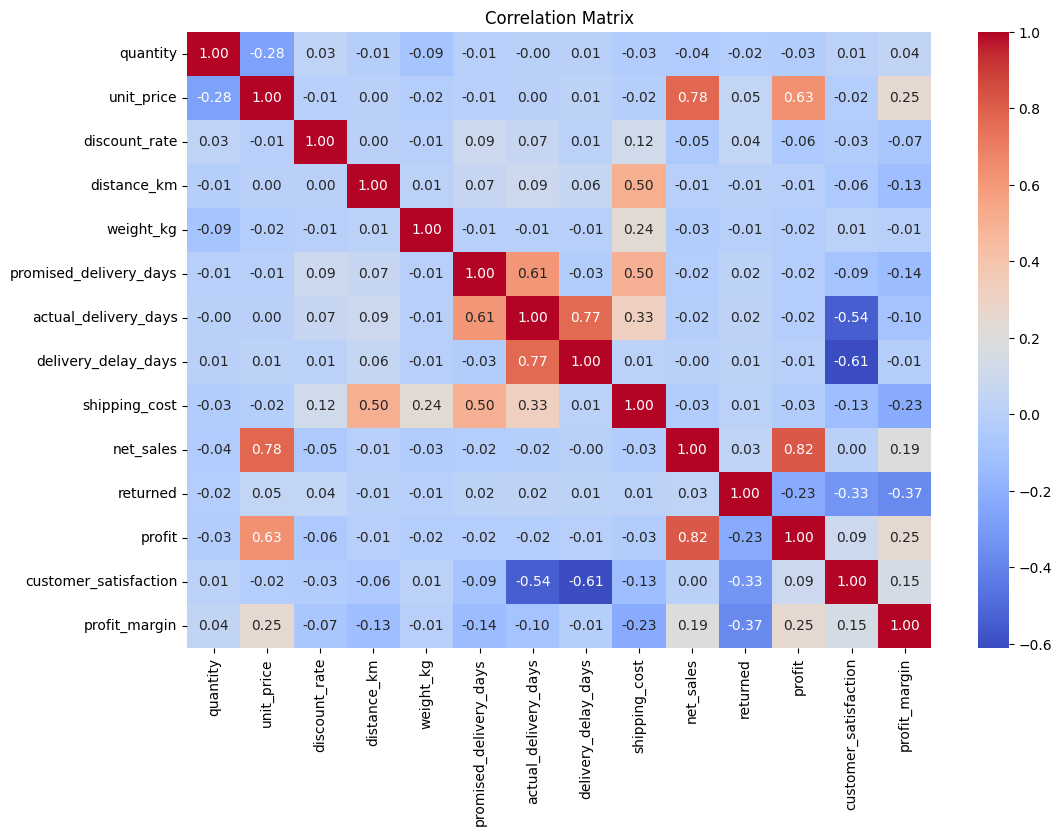

In [320]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

5.2 Interpretations

- What is the strongest positive correlation with profit?
- What is the strongest negative correlation with profit_margin?
- Is discount_rate more correlated with:
profit?
returns?
satisfaction?
- Does delivery_delay_days correlate with returns/satisfaction?




In [321]:
# Strongest Positive Correlation with Profit
corr_matrix['profit'].sort_values(ascending=False)

profit                    1.000000
net_sales                 0.819289
unit_price                0.632650
profit_margin             0.251427
customer_satisfaction     0.089628
distance_km              -0.007917
delivery_delay_days      -0.008572
weight_kg                -0.019799
actual_delivery_days     -0.020350
promised_delivery_days   -0.021285
shipping_cost            -0.027241
quantity                 -0.034685
discount_rate            -0.057064
returned                 -0.231072
Name: profit, dtype: float64

- Profit shows the strongest positive correlation with net_sales, because profit is derived from revenue after costs. Higher sales volume or pricing directly increases profit levels.

In [322]:
# Strongest Negative Correlation with Profit Margin
corr_matrix['profit_margin'].sort_values()

returned                 -0.371448
shipping_cost            -0.231438
promised_delivery_days   -0.140219
distance_km              -0.126793
actual_delivery_days     -0.100342
discount_rate            -0.072602
delivery_delay_days      -0.013748
weight_kg                -0.009273
quantity                  0.041519
customer_satisfaction     0.149900
net_sales                 0.187614
profit                    0.251427
unit_price                0.251467
profit_margin             1.000000
Name: profit_margin, dtype: float64

- Profit margin shows a strong negative correlation with returned. that means that as the return rate of a product increases, it's product margin tends to decrease significantly, and vice versa.

In [323]:
# Is discount_rate more correlated with profit, returns, or satisfaction?
# df['returned'] = df['returned'].astype(int)
corr_matrix_full = df[numeric_cols].corr()
corr_matrix_full['discount_rate'].sort_values(ascending=False)

discount_rate             1.000000
shipping_cost             0.116378
promised_delivery_days    0.093855
actual_delivery_days      0.066029
returned                  0.044476
quantity                  0.029685
delivery_delay_days       0.007764
distance_km               0.004058
unit_price               -0.008232
weight_kg                -0.009070
customer_satisfaction    -0.033215
net_sales                -0.052818
profit                   -0.057064
profit_margin            -0.072602
Name: discount_rate, dtype: float64

- Discount rate has a postive correlation with returns and negative correlation with satisfaction and profit.

In [324]:
# Does delivery_delay_days correlate with returns?
corr_matrix_full['delivery_delay_days'].sort_values(ascending=False)

delivery_delay_days       1.000000
actual_delivery_days      0.770085
distance_km               0.062282
unit_price                0.014263
returned                  0.013825
shipping_cost             0.010348
discount_rate             0.007764
quantity                  0.005056
net_sales                -0.003556
profit                   -0.008572
weight_kg                -0.008585
profit_margin            -0.013748
promised_delivery_days   -0.029988
customer_satisfaction    -0.610288
Name: delivery_delay_days, dtype: float64

- Delivery_delay_days shows a positive correlation with returns and a negative correlation with customer satisfaction.
- This suggests delayed deliveries reduce customer experience and increase likelihood of returns.

.

Correlation-Based Insights:

1. Profit strongly correlates with net_sales.
because profit is revenue-driven.

2. Discount_rate negatively correlates with profit_margin.
Indicates excessive discounting erodes profitability.

3. Shipping_cost positively correlates with distance_km and weight_kg.
Confirms logistics cost structure is distance/weight sensitive.

4. Delivery_delay_days negatively correlates with satisfaction.
Late deliveries reduce customer experience.

5. Delivery_delay_days positively correlates with returns.
Suggests service failure increases return likelihood.

6. Unit_price may show weak correlation with quantity.
Possible price elasticity behavior.

7. Profit_margin negatively correlates with shipping_cost.
High logistics costs compress margins.

6. EDA & Data Visualization

6.1 Univariate Analysis

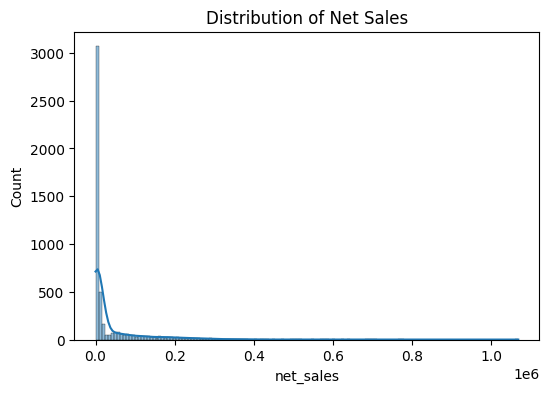

In [325]:
# Distribution of Net Sales
plt.figure(figsize=(6,4))
sns.histplot(df['net_sales'], kde=True)
plt.title("Distribution of Net Sales")
plt.show()

- Net sales distribution is heavily right-skewed, indicating that the majority of transactions are low-to-medium value orders, while a small number of high-value transactions drive a disproportionate share of total revenue.

- This suggests revenue concentration risk, where business performance may depend on a relatively small number of large orders.

Business Insight:

- Possible B2B or Corporate large orders.
- High-ticket electronics or bulk building materials.
- Opportunity to segment high-value customers.

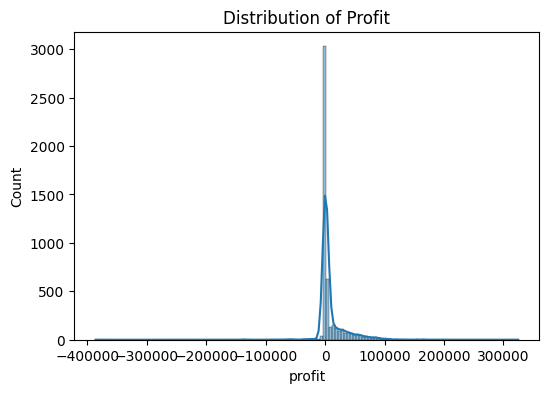

In [326]:
# Distribution of Profit
plt.figure(figsize=(6,4))
sns.histplot(df['profit'], kde=True)
plt.title("Distribution of Profit")
plt.show()

- Profit distribution shows a concentration around small positive margins, but the presence of negative profit values indicates loss-making transactions.
- The long right tail suggests that a small number of highly profitable orders significantly contribute to total profitability.

Business Insight:

- Some orders are structurally unprofitable
Likely drivers:
- High shipping cost
- Excessive discounts
- Returns
- Profit concentration risk again

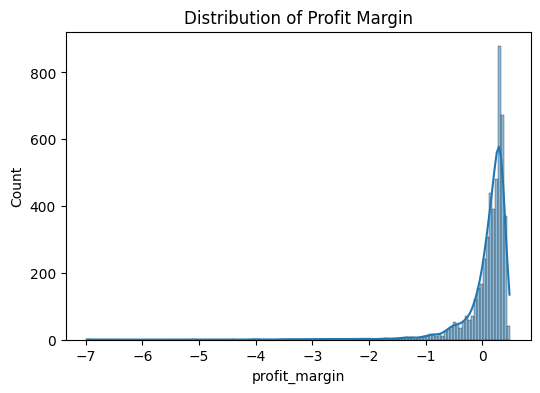

In [327]:
# Distribution of Profit Margin
plt.figure(figsize=(6,4))
sns.histplot(df['profit_margin'], kde=True)
plt.title("Distribution of Profit Margin")
plt.show()

- Profit margins are concentrated within a narrow positive range, but the long negative tail reveals substantial margin erosion in certain transactions.
- Extremely negative margins may indicate operational inefficiencies such as excessive discounts, high logistics costs, or return-related losses.

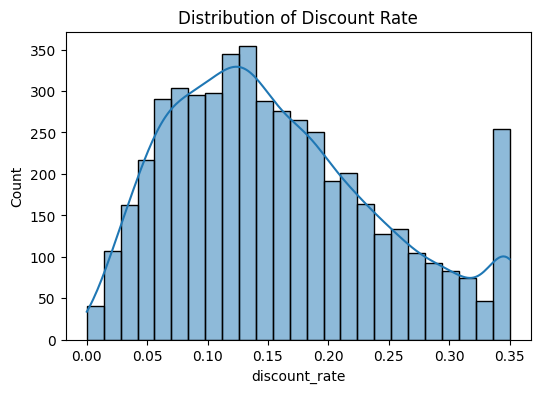

In [328]:
# Distribution of Discount Rate
plt.figure(figsize=(6,4))
sns.histplot(df['discount_rate'], kde=True)
plt.title("Distribution of Discount Rate")
plt.show()

- Most discounts are concentrated at lower levels, suggesting controlled promotional strategies.

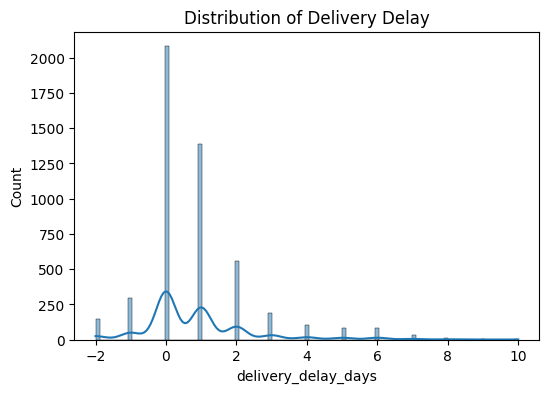

In [329]:
# Distribution of Delivery Delay
plt.figure(figsize=(6,4))
sns.histplot(df['delivery_delay_days'], kde=True)
plt.title("Distribution of Delivery Delay")
plt.show()

- Delay distribution shows a concentration around zero, but the right tail indicates late deliveries impacting SLA performance.

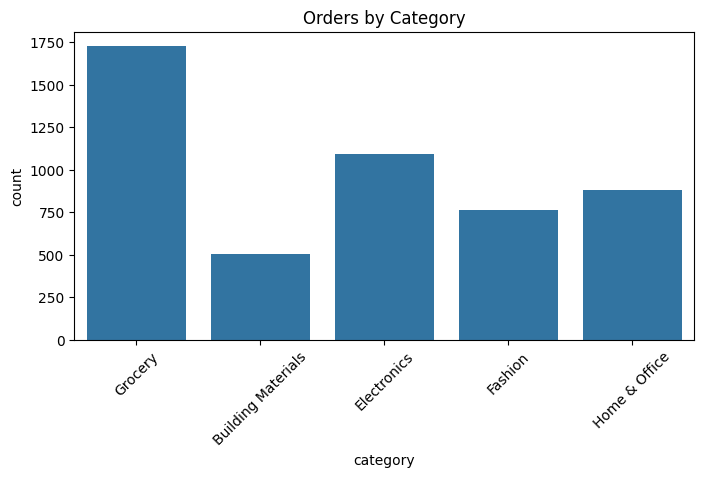

In [330]:
# Countplot: Category
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='category')
plt.xticks(rotation=45)
plt.title("Orders by Category")
plt.show()

- Certain categories dominate order volume, potentially driving overall revenue trends.

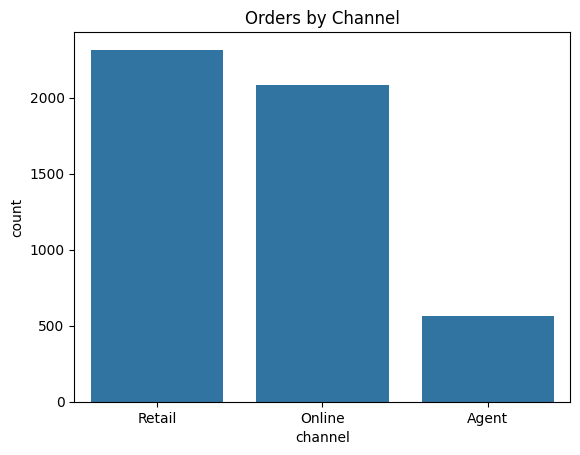

In [331]:
# Countplot: Channel
sns.countplot(data=df, x='channel')
plt.title("Orders by Channel")
plt.show()

- Retail channel dominate order count.

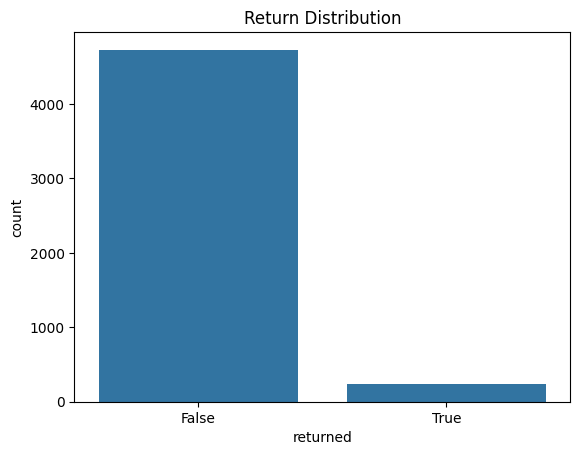

In [332]:
# Countplot: Returned
sns.countplot(data=df, x='returned')
plt.title("Return Distribution")
plt.show()

- Return rate show high volume of false(not returned).

6.2 Bivariate Analysis

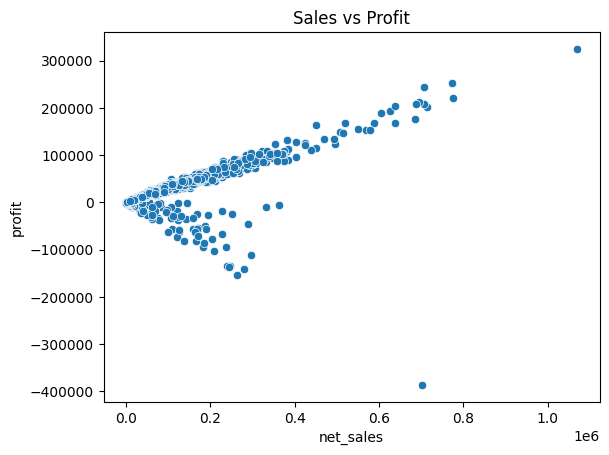

In [333]:
# Sales vs Profit (Scatter)
sns.scatterplot(data=df, x='net_sales', y='profit')
plt.title("Sales vs Profit")
plt.show()

- Strong positive relationship since profit is revenue-driven.

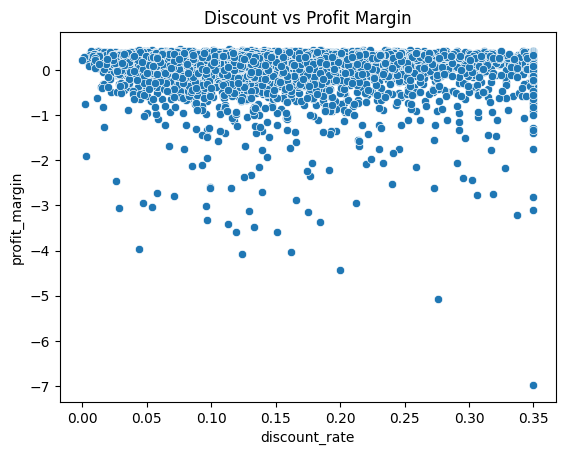

In [334]:
# Discount vs Profit Margin
sns.scatterplot(data=df, x='discount_rate', y='profit_margin')
plt.title("Discount vs Profit Margin")
plt.show()

- Increasing discounts appear to reduce profit margins

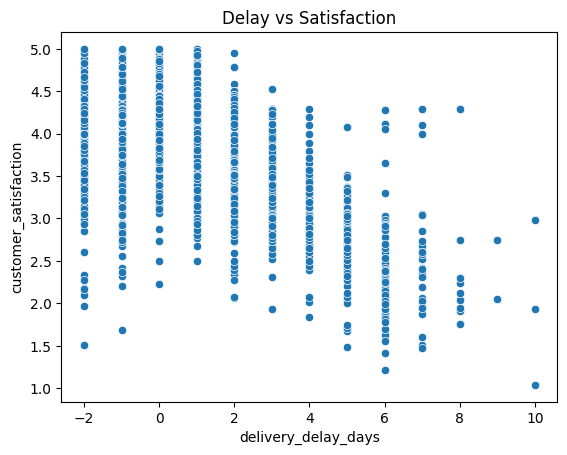

In [335]:
# Delay vs Satisfaction
sns.scatterplot(data=df, x='delivery_delay_days', y='customer_satisfaction')
plt.title("Delay vs Satisfaction")
plt.show()

- Negative trend likely: longer delays reduce satisfaction.

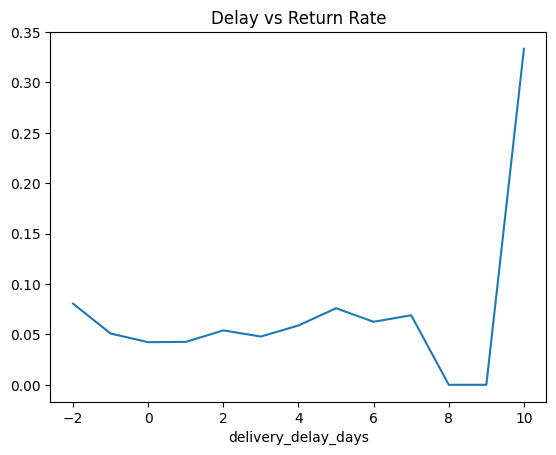

In [336]:
# Delay vs Return Rate (Grouped)
delay_returns = df.groupby('delivery_delay_days')['returned'].mean()

delay_returns.plot()
plt.title("Delay vs Return Rate")
plt.show()

- Return rates increase with higher delays, indicating service-level impact.

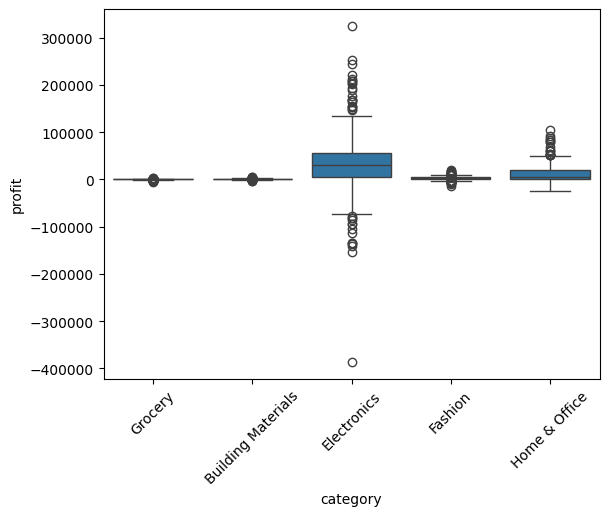

In [337]:
# Category vs Profit
sns.boxplot(data=df, x='category', y='profit')
plt.xticks(rotation=45)
plt.show()

- Some categories show high profit variability, suggesting margin instability.

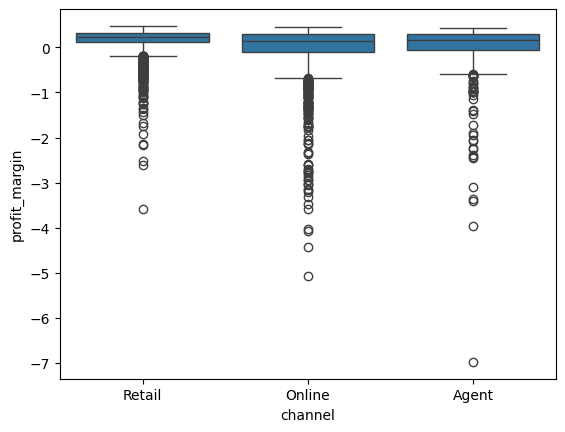

In [338]:
# Channel vs Profit Margin
sns.boxplot(data=df, x='channel', y='profit_margin')
plt.show()

- Channel profitability differences suggest structural cost variations.

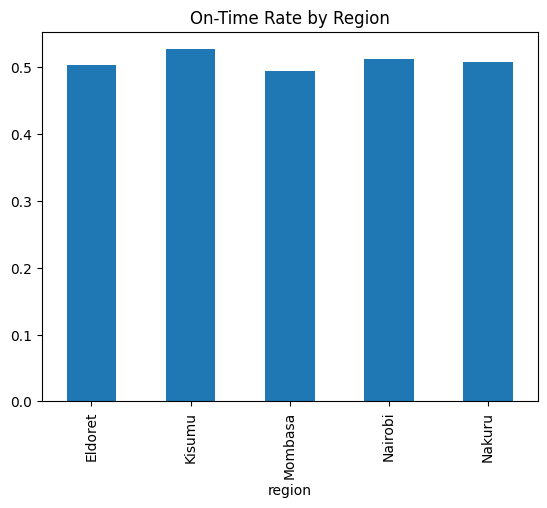

In [339]:
# Region vs On-Time Rate
region_sla = df.groupby('region')['on_time_flag'].mean()
region_sla.plot(kind='bar')
plt.title("On-Time Rate by Region")
plt.show()

- Certain regions underperform on SLA, indicating logistics inefficiencies.

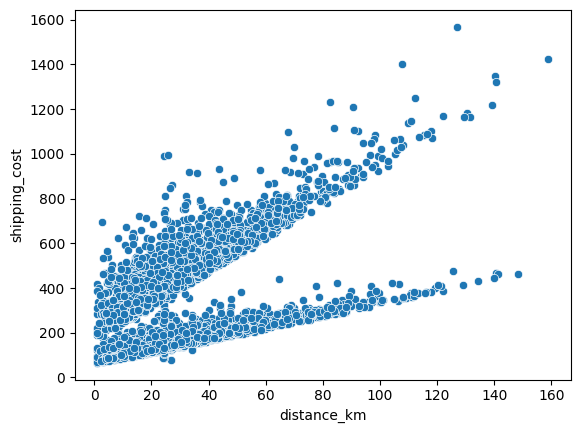

In [340]:
# Distance vs Shipping Cost
sns.scatterplot(data=df, x='distance_km', y='shipping_cost')
plt.show()

- Strong positive relationship confirms cost-to-distance sensitivity.

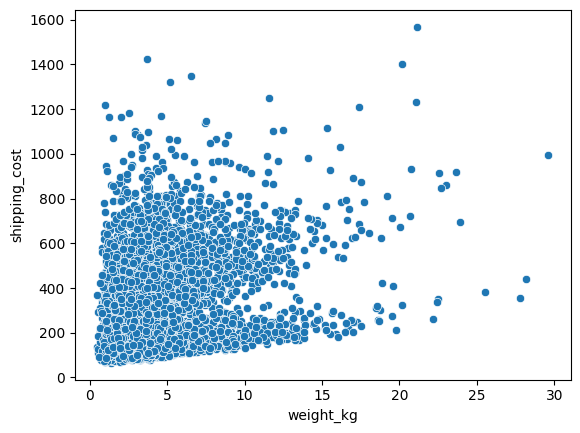

In [341]:
# Weight vs Shipping Cost
sns.scatterplot(data=df, x='weight_kg', y='shipping_cost')
plt.show()

- Heavier shipments incur higher costs.

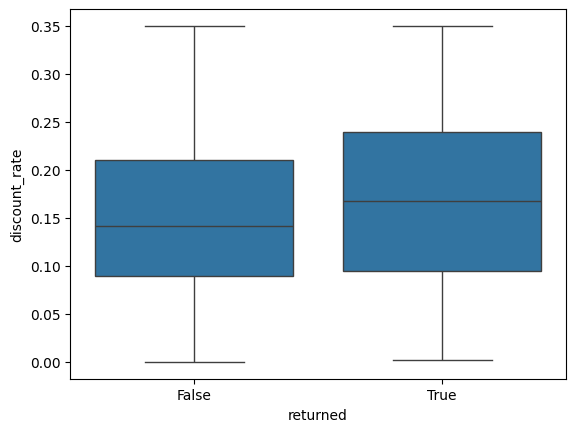

In [342]:
# Discount vs Returns
sns.boxplot(data=df, x='returned', y='discount_rate')
plt.show()

- Returned orders may show higher average discounts, suggesting price-driven purchases.

6.3 Multivariate Analysis

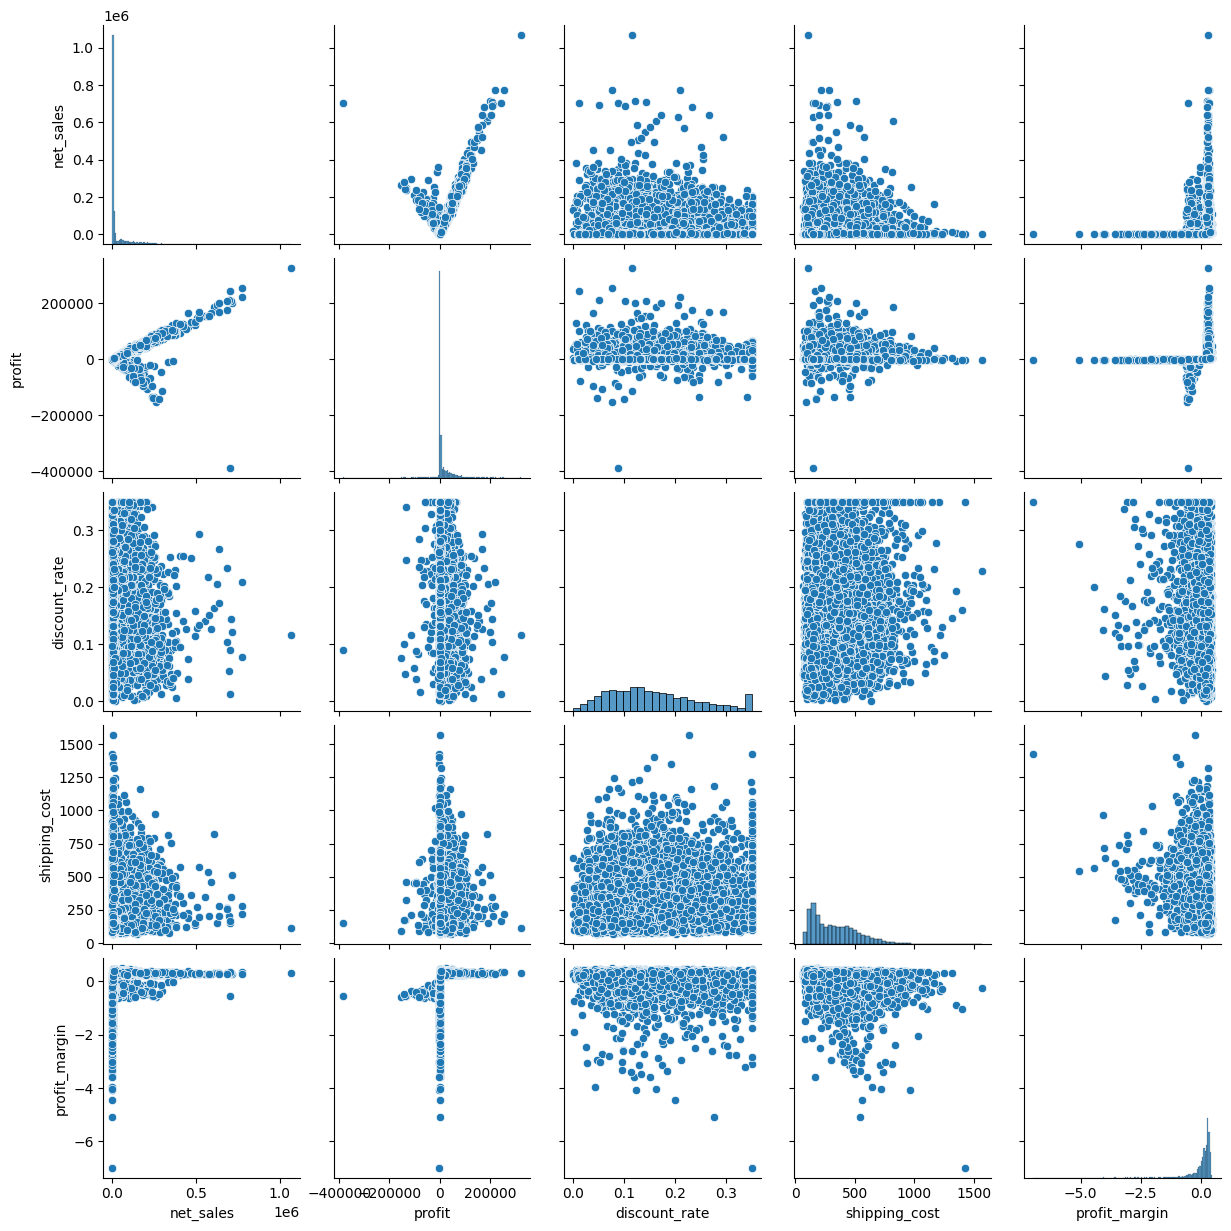

In [343]:
# Pairplot
sns.pairplot(df[['net_sales','profit','discount_rate','shipping_cost','profit_margin']])
plt.show()

- Reveals clustering patterns and nonlinear relationships.

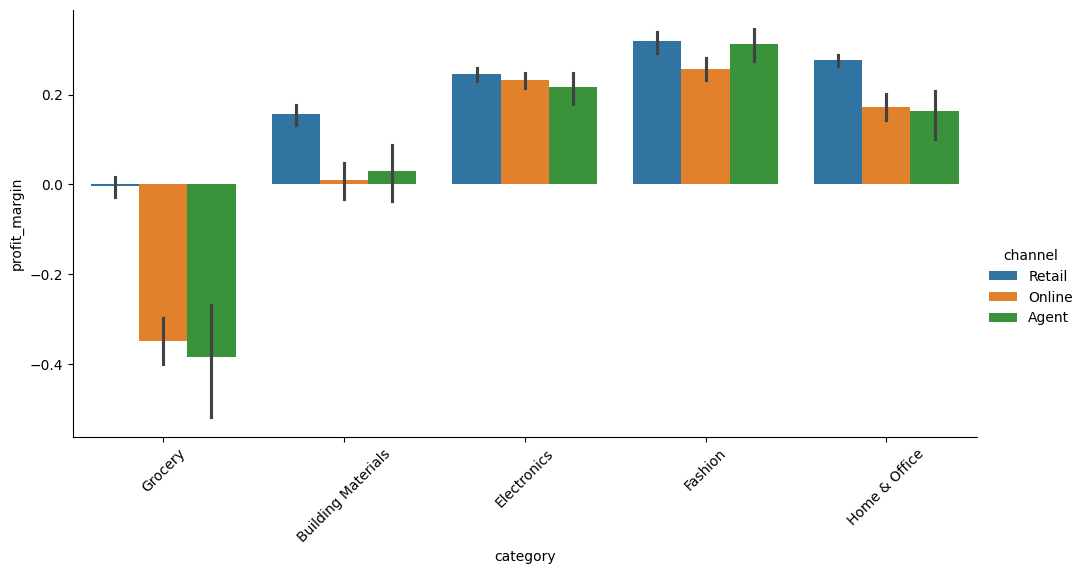

In [344]:
# Faceted Profit Margin by Category & Channel
sns.catplot(data=df,
            x='category',
            y='profit_margin',
            hue='channel',
            kind='bar',
            height=5,
            aspect=2)

plt.xticks(rotation=45)
plt.show()

- Profit margin varies significantly across category-channel combinations, revealing potential profit leak segments.

- The EDA findings suggest structural profitability differences across channels and regions, with logistics performance emerging as a key operational driver of both customer satisfaction and returns.

7. Investigator Tasks
Task A — Profit Leak Diagnosis

In [345]:
# a category + channel combination that consistently produces negative profit
# evidence table (grouped summary)
profit_leak_table = (
    df.groupby(['category', 'channel'])
      .agg(
          mean_profit=('profit', 'mean'),
          mean_profit_margin=('profit_margin', 'mean'),
          total_profit=('profit', 'sum')
      )
      .reset_index()
      .sort_values(by='mean_profit')   # worst first
)

profit_leak_table


,category,channel,mean_profit,mean_profit_margin,total_profit
9,Grocery,Agent,-133.939454,-0.383973,-24510.92
10,Grocery,Online,-130.121687,-0.348548,-94077.98
11,Grocery,Retail,202.626935,-0.004464,165951.46
1,Building Materials,Online,361.073493,0.009302,75464.36
0,Building Materials,Agent,503.718730,0.030105,31734.28
2,Building Materials,Retail,676.460940,0.156775,158291.86
7,Fashion,Online,2462.738997,0.257459,834868.52
8,Fashion,Retail,2796.857355,0.318812,962118.93
6,Fashion,Agent,2984.827564,0.312794,232816.55
12,Home & Office,Agent,10389.368095,0.162769,1090883.65


In [346]:
# Show Only Loss-Making Segments
loss_segments = profit_leak_table[
    profit_leak_table['mean_profit'] < 0
]

loss_segments

,category,channel,mean_profit,mean_profit_margin,total_profit
9,Grocery,Agent,-133.939454,-0.383973,-24510.92
10,Grocery,Online,-130.121687,-0.348548,-94077.98


Supporting Plot

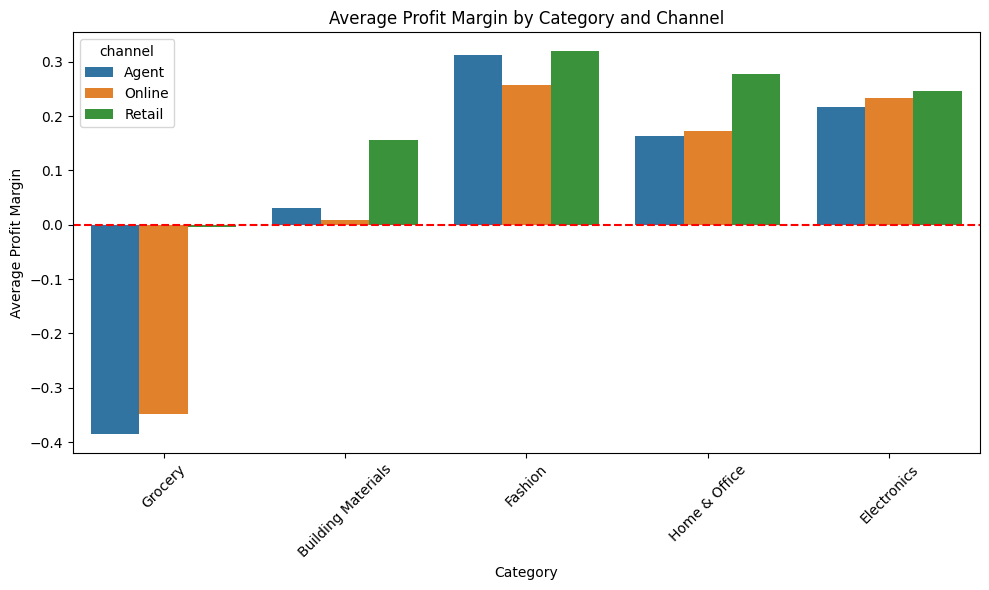

In [347]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=profit_leak_table,
    x='category',
    y='mean_profit_margin',
    hue='channel'
)

plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profit Margin by Category and Channel')
plt.xticks(rotation=45)
plt.ylabel('Average Profit Margin')
plt.xlabel('Category')

plt.tight_layout()
plt.show()

The Grocery category exhibits consistent negative profitability in both the Agent and Online channels, with Online Grocery generating the largest total loss (-94,078) and a severe average margin of -35%. This suggests that operational costs such as last-mile delivery, spoilage risk, discounting, and commission structures are exceeding revenue contribution. Grocery products typically have low margins, and when combined with distribution costs, profitability becomes structurally negative in non-retail channels.

In [348]:
# evidence table (grouped summary)
# regions where shipping_cost overwhelms margins
region_shipping_summary = (
    df.groupby('region')
      .agg(
          mean_shipping_cost=('shipping_cost', 'mean'),
          mean_profit=('profit', 'mean'),
          mean_profit_margin=('profit_margin', 'mean'),
          total_profit=('profit', 'sum')
      )
      .reset_index()
)

region_shipping_summary = region_shipping_summary.sort_values(by='mean_profit')

region_shipping_summary

,region,mean_shipping_cost,mean_profit,mean_profit_margin,total_profit
1,Kisumu,340.249673,9350.033554,0.071413,9733384.93
0,Eldoret,326.192734,9404.870894,0.076880,9254392.96
2,Mombasa,363.145272,9442.639476,0.065330,9546508.51
4,Nakuru,335.803660,9774.574628,0.065140,9188100.15
3,Nairobi,329.391621,11168.468075,0.111860,11023277.99


In [349]:
# To flag suspicious regions
region_shipping_summary[
    region_shipping_summary['mean_shipping_cost'] > 
    region_shipping_summary['mean_profit']
]

,region,mean_shipping_cost,mean_profit,mean_profit_margin,total_profit


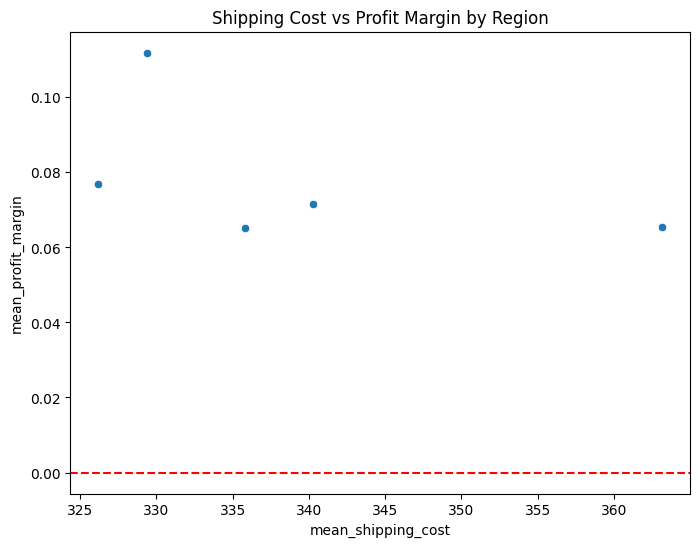

In [350]:
# Supporting Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=region_shipping_summary,
    x='mean_shipping_cost',
    y='mean_profit_margin'
)

plt.axhline(0, color='red', linestyle='--')
plt.title('Shipping Cost vs Profit Margin by Region')

plt.show()

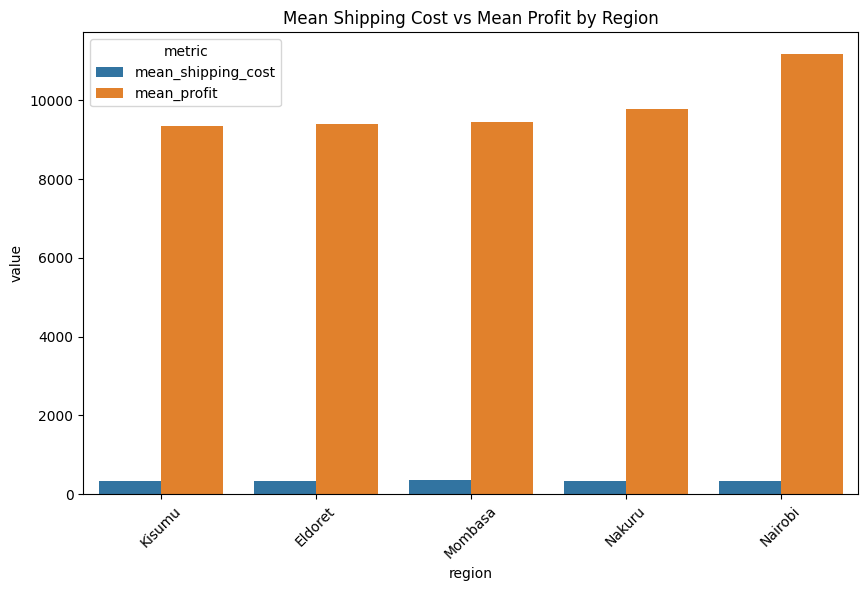

In [351]:
region_shipping_summary_melted = region_shipping_summary.melt(
    id_vars='region',
    value_vars=['mean_shipping_cost', 'mean_profit'],
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=region_shipping_summary_melted,
    x='region',
    y='value',
    hue='metric'
)

plt.title('Mean Shipping Cost vs Mean Profit by Region')
plt.xticks(rotation=45)
plt.show()

Evidence:

Regional analysis shows that average shipping cost ranges between 326–363, while mean profit per transaction ranges between 9,350–11,168. In no region does shipping cost exceed profit contribution.

Business Interpretation:

Shipping cost does not structurally overwhelm margins in any region. Although Mombasa has the highest average shipping cost (363), its average profit remains significantly higher (9,443). This indicates that regional logistics are operating within sustainable profitability levels.

In [352]:
# Create Discount Bands
import pandas as pd

# Create discount bands
df['discount_band'] = pd.cut(
    df['discount_rate'],
    bins=[0, 0.05, 0.15, 0.30, 1],
    labels=['0-5%', '5-15%', '15-30%', '30%+']
)

In [353]:
# evidence table (grouped summary)
# discounts that fail to increase net_sales but reduce profit_margin
discount_summary = (
    df.groupby('discount_band')
      .agg(
          mean_net_sales=('net_sales', 'mean'),
          mean_profit_margin=('profit_margin', 'mean'),
          mean_profit=('profit', 'mean'),
          total_profit=('profit', 'sum')
      )
      .reset_index()
)

discount_summary

C:\Users\user\AppData\Local\Temp\ipykernel_4768\3918984118.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('discount_band')


,discount_band,mean_net_sales,mean_profit_margin,mean_profit,total_profit
0,0-5%,46919.541166,0.118133,12309.984081,5490252.90
1,5-15%,40824.921040,0.096406,10731.403593,23533968.08
2,15-30%,35726.005863,0.068002,9191.007541,17527251.38
3,30%+,25510.938221,-0.015220,5265.022284,2190249.27


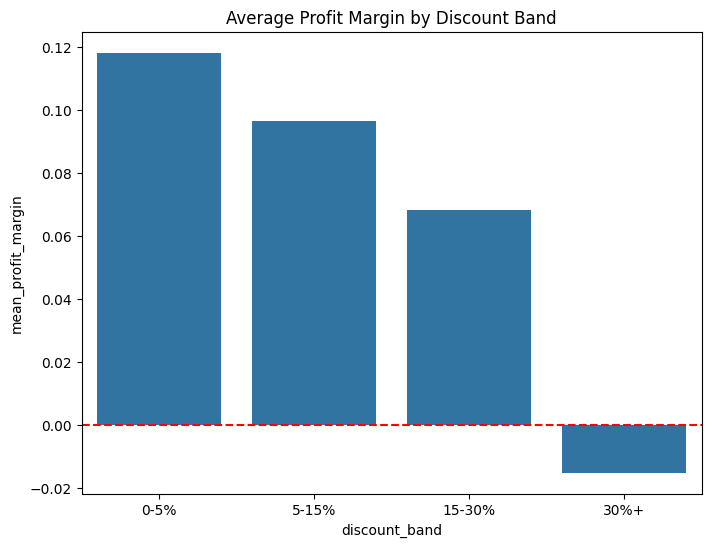

In [354]:
# Supporting plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=discount_summary,
    x='discount_band',
    y='mean_profit_margin'
)

plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profit Margin by Discount Band')

plt.show()

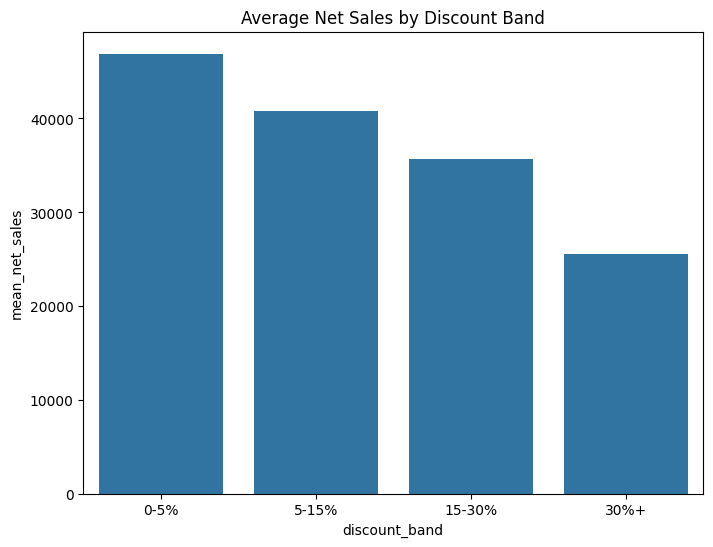

In [355]:
# Net Sales vs Discount Band
plt.figure(figsize=(8,6))

sns.barplot(
    data=discount_summary,
    x='discount_band',
    y='mean_net_sales'
)

plt.title('Average Net Sales by Discount Band')

plt.show()

The analysis reveals that increasing discount levels consistently reduce both net sales and profitability. While average net sales decline from 46,919 at low discount levels (0–5%) to 25,510 at 30%+, profit margins collapse from 11.8% to -1.5%. This indicates that aggressive discounting does not stimulate sufficient demand to offset margin loss and instead results in structural value destruction.

Strategic Recommendation:
Discounts above 15% should be carefully reviewed or capped, as they materially reduce profitability without driving meaningful sales uplift. A targeted promotion strategy based on product elasticity rather than blanket high discounts is recommended.

Task B — Returns Driver Model (EDA only)

In [356]:
# Create Return Flag
df['return_flag'] = df['returned']   # if already 0/1

In [357]:
# Return Rate by Category
returns_category = (
    df.groupby('category')
      .agg(
          return_rate=('return_flag', 'mean'),
          avg_profit_margin=('profit_margin', 'mean')
      )
      .reset_index()
      .sort_values(by='return_rate', ascending=False)
)

returns_category

,category,return_rate,avg_profit_margin
2,Fashion,0.086728,0.290865
1,Electronics,0.063187,0.236607
3,Grocery,0.034783,-0.188941
4,Home & Office,0.028441,0.219966
0,Building Materials,0.025692,0.080091


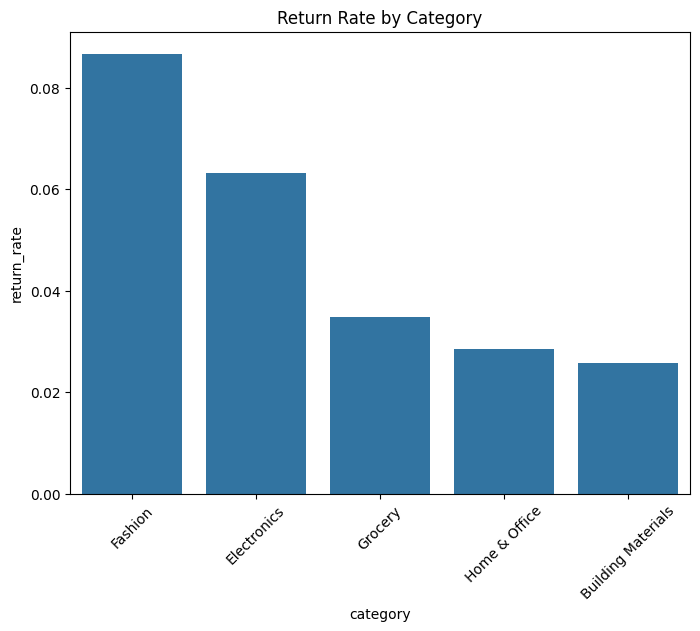

In [358]:
# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=returns_category,
            x='category',
            y='return_rate')
plt.xticks(rotation=45)
plt.title('Return Rate by Category')
plt.show()

Key Insights:
1. Fashion Has the Highest Return Rate (8.67%)
- Almost 3x higher than Building Materials.
Likely drivers:

- Size mismatch
- Style preference
- Post-purchase regret
- Impulse buying

2. Electronics Also Has Elevated Returns (6.32%)
Possible causes:

- Product defects
- Compatibility issues
- Customer misunderstanding of features

Hypotheses Based on Category Analysis
🔹 Hypothesis 1 — Fashion Returns Are Experience-Driven
- Customers are more likely to return Fashion items due to fit, size, or preference mismatch after physical inspection.

🔹 Hypothesis 2 — Electronics Returns Are Feature/Expectation Driven
- Electronics may experience returns due to performance expectations, technical compatibility issues, or perceived defects.

Proposed Interventions:
1. Intervention 1 — Reduce Fashion Returns
- Provide enhanced size guides
- Add customer review-based sizing feedback
- Offer virtual fitting tools (if online)
- Improve product imagery
This targets the highest-risk category.

2. Intervention 2 — Improve Electronics Pre-Purchase Clarity
- Clear compatibility guides
- FAQ sections
- Better technical specifications
- Customer support before purchase
Reduce expectation mismatch.

Summary:
Category-level analysis indicates that Fashion exhibits the highest return rate (8.67%), followed by Electronics (6.32%). These elevated return levels are likely driven by post-purchase dissatisfaction, size mismatch, and product expectation gaps. In contrast, Grocery shows low return rates despite negative margins, suggesting structural pricing challenges rather than return-related losses. Operational focus should prioritize reducing returns in high-risk categories such as Fashion and Electronics.

In [359]:
# Return Rate by Discount Band
returns_discount = (
    df.groupby('discount_band')
      .agg(return_rate=('return_flag', 'mean'))
      .reset_index()
)

returns_discount

C:\Users\user\AppData\Local\Temp\ipykernel_4768\2681644013.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('discount_band')


,discount_band,return_rate
0,0-5%,0.044843
1,5-15%,0.036480
2,15-30%,0.055585
3,30%+,0.064904


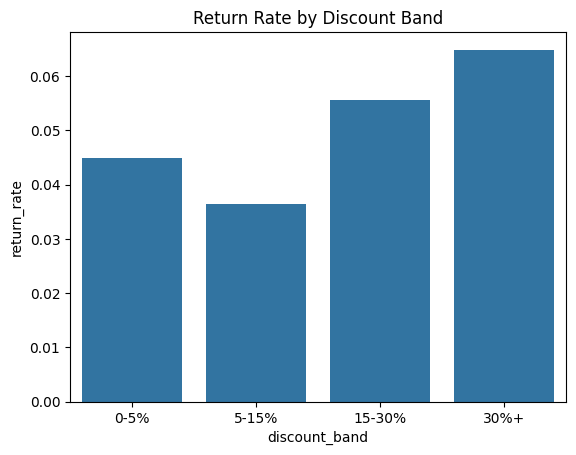

In [360]:
# Plot
sns.barplot(data=returns_discount,
            x='discount_band',
            y='return_rate')
plt.title('Return Rate by Discount Band')
plt.show()

Hypothesis:
Deep discounting (15%+) increases return probability due to impulse purchasing behavior and lower customer commitment to the product.

Summary:
Return rates increase significantly for discounts above 15%, rising to 6.49% in the 30%+ band. This suggests that aggressive discounting encourages impulse buying and increases post-purchase dissatisfaction. Combined with earlier findings that high discounts reduce profit margins and fail to increase net sales, this indicates that deep discount strategies are structurally value-destructive.

Intervention (Pricing Policy):
Implement a discount cap at 15% for most categories and use targeted promotions based on product elasticity rather than blanket high discounts.

In [361]:
# Return Rate by Channel
returns_channel = (
    df.groupby('channel')
      .agg(return_rate=('return_flag', 'mean'))
      .reset_index()
      .sort_values(by='return_rate', ascending=False)
)

returns_channel

,channel,return_rate
0,Agent,0.049383
1,Online,0.048534
2,Retail,0.044924


In [362]:
# Return Rate by Segment
returns_segment = (
    df.groupby('segment')
      .agg(return_rate=('return_flag', 'mean'))
      .reset_index()
      .sort_values(by='return_rate', ascending=False)
)

returns_segment

,segment,return_rate
0,Consumer,0.049765
2,Sme,0.045552
1,Corporate,0.027548


Task C — Service Level Performance

Define SLA:
On-time delivery = delay <= 0

In [363]:
# Create On-Time Flag
df['on_time'] = (df['delivery_delay_days'] <= 0).astype(int)

In [364]:
# On-Time Rate — Overall
overall_on_time = df['on_time'].mean()
overall_on_time *100

np.float64(50.87648599637317)

In [365]:
#On-Time Rate by Region
on_time_region = (
    df.groupby('region')
      .agg(on_time_rate=('on_time', 'mean'))
      .reset_index()
      .sort_values(by='on_time_rate')
)

on_time_region

,region,on_time_rate
2,Mombasa,0.493571
0,Eldoret,0.503049
4,Nakuru,0.507447
3,Nairobi,0.512665
1,Kisumu,0.526417


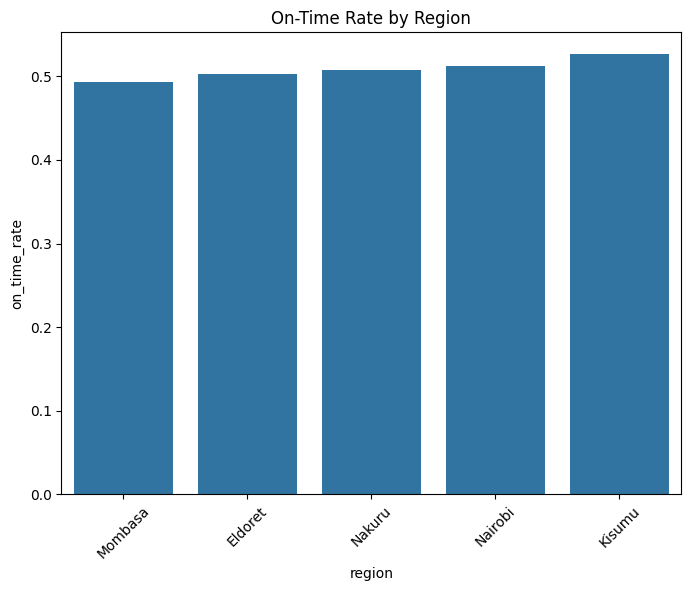

In [366]:
# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.barplot(data=on_time_region,
            x='region',
            y='on_time_rate')

plt.title('On-Time Rate by Region')
plt.xticks(rotation=45)
plt.show()

In [367]:
# On-Time Rate by Channel
on_time_channel = (
    df.groupby('channel')
      .agg(on_time_rate=('on_time', 'mean'))
      .reset_index()
      .sort_values(by='on_time_rate')
)

on_time_channel

,channel,on_time_rate
1,Online,0.500240
2,Retail,0.511879
0,Agent,0.527337


In [368]:
# Worst 5 City-Level Areas
on_time_city = (
    df.groupby('city')
      .agg(on_time_rate=('on_time', 'mean'))
      .reset_index()
      .sort_values(by='on_time_rate')
)

worst_5_cities = on_time_city.head(5)
worst_5_cities

,city,on_time_rate
14,Molo,0.411215
5,Kasarani,0.453039
4,Kapsoya,0.482659
6,Kisauni,0.492366
11,Likoni,0.494208


Summary:
The overall on-time performance across regions is approximately 50%, indicating that half of all deliveries are delayed. Mombasa is the weakest performing region, while Molo city exhibits severe underperformance with only 41% on-time delivery. Channel analysis shows that Online orders have the lowest SLA compliance, suggesting last-mile delivery inefficiencies.

Operational Improvements
1. Regional Fulfillment Optimization
Establish micro-fulfillment hubs near:
- Molo
- Coastal regions (Mombasa, Likoni, Kisauni)
This reduces long-haul transport delays.

2. Channel-Specific Delivery Strategy
Since Online performs worst:
- Improve courier selection
- Implement route optimization algorithms
Use delivery performance scoring per courier

3. Realistic Delivery Promise System
If delay is high:
- Promised delivery days may be unrealistic.
- Adjust delivery expectations based on region performance.
This improves SLA compliance even without changing logistics speed.

8. Executive Summary

1. High Discounts Drive Higher Returns
Return rates increase as discount levels rise:

0–5% → 4.48%

5–15% → 3.65% (lowest)

15–30% → 5.56%

30%+ → 6.49% (highest)

Deep discounts (30%+) are strongly associated with higher product returns, which likely reduces net profitability.

2. Moderate Discounts Perform Best:
The 5–15% discount band has the lowest return rate (3.65%), suggesting this range balances demand stimulation and product satisfaction.

3. On-Time Performance is Critically Low:
Overall on-time delivery is roughly around 50%, meaning 1 out of every 2 orders is late.
This represents a major operational risk and customer satisfaction concern.

4. Mombasa is the Weakest Region:

On-time rate by region:
Mombasa → 49.36% (worst)
Eldoret → 50.30%
Nakuru → 50.74%
Nairobi → 51.27%
Kisumu → 52.64% (best)

Regional operational inconsistencies exist.

5. Agent Channel Has Best SLA Performance:

On-time rate by channel:
Agent → 52.73% (best)
Retail → 51.19%
Online → 50.02% (worst)

Online channel may have logistics inefficiencies or demand volatility issues.

6. Molo is a Critical Bottleneck:

Worst 5 cities (on-time rate):
Molo → 41.12%
Kasarani → 45.30%
Kapsoya → 48.27%
Kisauni → 49.24%
Likoni → 49.42%

Molo is significantly underperforming and likely driving regional SLA decline.

7. SLA Issues Likely Increase Return Rates:

Late deliveries often lead to:
Customer dissatisfaction
Order cancellations
Higher product returns

There is likely a correlation between delay and return behavior.

8. Online Channel Risk Profile:

Online has:
Lower SLA performance
Likely higher returns (if cross-analyzed)
This channel may be scaling faster than logistics capacity.

9.  Regional Equity Problem:

Difference between best (Kisumu 52.6%) and worst (Mombasa 49.3%) shows uneven operational quality across regions.

Standardization is missing.

10. Profitability Pressure from Two Sides:

Profit margins are being squeezed by:
High discount levels (especially 30%+)
Rising return rates
Poor on-time performance

These combined factors reduce contribution margin and customer lifetime value.

Business Recommendations
1. Optimize Discount Policy
- Reduce 30%+ discount campaigns.
- Focus promotions in 5–15% band (proven lowest return rate).
- Implement margin-based discount controls.

2. Channel Strategy Adjustment
- Strengthen Online logistics capacity.
- Re-evaluate fulfillment model for Online orders.
- Consider differentiated SLA promises per channel.

3. Region-Based Pricing & Campaign Strategy
- Avoid aggressive promotions in weak SLA regions.
- Align marketing spend with operational readiness.

Operational Recommendations
1. Fix Worst 5 Cities Immediately
- Conduct route optimization in Molo and Kasarani.
- Increase delivery fleet or partner capacity.
- Implement city-level SLA monitoring dashboards.

2. Introduce SLA Escalation Rules
- Auto-flag orders at risk of delay.
- Prioritize orders approaching SLA breach.
- Daily regional SLA reporting.

3. Improve Returns Handling & Packaging
- Investigate why high-discount items return more.
- Improve product description accuracy (especially online).
- Improve packaging to reduce damage-related returns.

Conclusion

The analysis reveals that the company’s performance challenges are driven by a combination of aggressive discounting, high return rates, and weak delivery reliability.

Operationally, on-time delivery performance is critically low at around 50%, meaning half of all orders fail to meet SLA expectations. Certain regions (notably Mombasa) and cities (especially Molo) are significantly underperforming, indicating logistics inefficiencies and uneven service standards across locations. The Online channel also shows weaker SLA performance compared to Agent and Retail channels.

From a profitability perspective, deeper discount bands (especially 30%+) are associated with the highest return rates, suggesting that excessive price reductions may attract low-intent buyers or reduce perceived product value. In contrast, moderate discounts (5–15%) appear to balance sales stimulation and customer satisfaction more effectively.

Overall, the business faces a dual pressure:
- Margin erosion from high discounting and returns
- Customer dissatisfaction due to delivery delays

To improve performance sustainably, management must align pricing strategy, channel management, and logistics execution. By tightening discount controls, standardizing SLA performance across regions, and addressing city-level bottlenecks, the company can enhance profitability, improve customer experience, and build long-term competitive advantage.